<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/Branchwise_Accounts_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [39]:
DATA_PATH = '/content/lag_data.csv'
TARGET_COLUMN = 'CountofAccountID'
BRANCHID_TO_PREDICT = 2

COLUMNS_TO_USE = [
    'Date',
    'BranchID',
     TARGET_COLUMN
]

LAGS = [1, 2, 3, 7, 14, 30]

FEATURES = [
    'lag_1',
    'lag_2',
    'ema_7',
    'lag_3',
    'diff_1'
]

TRAIN_END_DATE = '2026-04-01'

MODEL_PARAMS = {
    'n_estimators': 5000,
    'learning_rate': 0.03,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'objective': 'reg:squarederror'
}


In [29]:
def load_data(file_path, columns):
    df = pd.read_csv(file_path)

    data_df = df[columns].copy()

    data_df['Date'] = pd.to_datetime(
        data_df['Date'],
        dayfirst=True
    )

    data_df = data_df.sort_values(
        ['BranchID', 'Date']
    )

    return data_df

In [30]:
def clip_outliers(data_df, target_col):
    upper = data_df[target_col].quantile(0.99)

    data_df[target_col] = np.clip(
        data_df[target_col],
        None,
        upper
    )

    return data_df


def create_lag_features(data_df, target_col, lags):
    for lag in lags:
        data_df[f'lag_{lag}'] = (
            data_df
            .groupby('BranchID')[target_col]
            .shift(lag)
        )

    return data_df


def create_ema_features(data_df, target_col):
    for span in [7, 14, 30]:
        data_df[f'ema_{span}'] = (
            data_df
            .groupby('BranchID')[target_col]
            .transform(
                lambda x: x.shift(1).ewm(span=span).mean()
            )
        )

    return data_df


def create_diff_features(data_df, target_col):
    data_df['diff_1'] = (
        data_df
        .groupby('BranchID')[target_col]
        .diff(1)
    )

    data_df['diff_7'] = (
        data_df
        .groupby('BranchID')[target_col]
        .diff(7)
    )

    return data_df


def create_pct_change_features(data_df, target_col):
    data_df['pct_change_1'] = (
        data_df
        .groupby('BranchID')[target_col]
        .pct_change(1)
    )

    return data_df


def create_date_features(data_df):
    data_df['day'] = data_df['Date'].dt.day

    data_df['month'] = data_df['Date'].dt.month

    data_df['dayofweek'] = (
        data_df['Date'].dt.dayofweek
    )

    data_df['weekofyear'] = (
        data_df['Date']
        .dt
        .isocalendar()
        .week
        .astype(int)
    )

    data_df['sin_week'] = np.sin(
        2 * np.pi * data_df['dayofweek'] / 7
    )

    data_df['cos_week'] = np.cos(
        2 * np.pi * data_df['dayofweek'] / 7
    )

    return data_df


def encode_branch(data_df):
    le = LabelEncoder()

    data_df['BranchID_encoded'] = (
        le.fit_transform(data_df['BranchID'])
    )

    return data_df, le


def clean_data(data_df, target_col):
    data_df = data_df.dropna().reset_index(drop=True)

    data_df['target'] = data_df[target_col]

    data_df = data_df.replace(
        [np.inf, -np.inf],
        np.nan
    )

    data_df = data_df.dropna().reset_index(drop=True)

    return data_df


def prepare_dataset(data_df):
    data_df = clip_outliers(
        data_df,
        TARGET_COLUMN
    )

    data_df = create_lag_features(
        data_df,
        TARGET_COLUMN,
        LAGS
    )

    data_df = create_ema_features(
        data_df,
        TARGET_COLUMN
    )

    data_df = create_diff_features(
        data_df,
        TARGET_COLUMN
    )

    data_df = create_pct_change_features(
        data_df,
        TARGET_COLUMN
    )

    data_df = create_date_features(data_df)

    data_df, le = encode_branch(data_df)

    data_df = clean_data(
        data_df,
        TARGET_COLUMN
    )

    return data_df, le

In [31]:
def split_data(data_df, split_date, features):
    train_df = data_df[
        data_df['Date'] < split_date
    ]

    test_df = data_df[
        data_df['Date'] >= split_date
    ]

    X_train = train_df[features]
    y_train = train_df['target']

    X_test = test_df[features]
    y_test = test_df['target']

    return (
        train_df,
        test_df,
        X_train,
        y_train,
        X_test,
        y_test
    )

In [32]:
def train_model(
    X_train,
    y_train,
    X_test,
    y_test,
    params
):
    model = XGBRegressor(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_test, y_test)],
        verbose=100
    )

    return model

In [33]:
def evaluate_model(y_test, preds):
    mae = mean_absolute_error(y_test, preds)

    rmse = np.sqrt(
        mean_squared_error(y_test, preds)
    )

    mape = np.mean(
        np.abs((y_test - preds) / y_test)
    ) * 100

    print("\n====================")
    print("MODEL PERFORMANCE")
    print("====================")

    print(f"MAE : {mae:,.2f}")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAPE: {mape:.2f}%")

    return mae, rmse, mape

In [34]:
def create_results_df(test_df, y_test, preds):
    results_df = test_df[
        ['Date', 'BranchID']
    ].copy()

    results_df['Actual'] = y_test.values

    results_df['Predicted'] = preds

    return results_df


def feature_importance_df(model, features):
    importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by='Importance',
        ascending=False
    )

    return importance_df

In [35]:
def plot_feature_importance(importance_df):
    plt.figure(figsize=(12, 8))

    plt.barh(
        importance_df['Feature'],
        importance_df['Importance']
    )

    plt.gca().invert_yaxis()

    plt.title('Feature Importance')

    plt.xlabel('Importance')

    plt.tight_layout()

    plt.show()


def plot_actual_vs_predicted(
    results_df,
    branch_id
):
    branch_df = results_df[
        results_df['BranchID'] == branch_id
    ].sort_values('Date')

    plt.figure(figsize=(18, 6))

    plt.plot(
        branch_df['Date'],
        branch_df['Actual'],
        label='Actual',
        linewidth=2,
        marker='o'
    )

    plt.plot(
        branch_df['Date'],
        branch_df['Predicted'],
        label='Predicted',
        linewidth=2,
        marker='x'
    )

    plt.title(
        f'Actual vs Predicted - Branch {branch_id}'
    )

    plt.xlabel('Date')

    plt.ylabel(TARGET_COLUMN)

    plt.legend()

    plt.grid()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()


def plot_forecast(forecast_df, branch_id):
    plt.figure(figsize=(18, 6))

    plt.plot(
        forecast_df['Date'],
        forecast_df['Predicted_PAR'],
        marker='o',
        linewidth=2
    )

    plt.title(
        f'Next Forecast - Branch {branch_id}'
    )

    plt.xlabel('Date')

    plt.ylabel('Predicted PAR')

    plt.grid()

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [36]:
def forecast_future(
    model,
    data_df,
    branch_id,
    forecast_horizon,
    features,
    le
):
    future_predictions = []

    branch_history = data_df[
        data_df['BranchID'] == branch_id
    ].copy()

    branch_history = branch_history.sort_values(
        'Date'
    )

    last_date = branch_history['Date'].max()

    for i in range(1, forecast_horizon + 1):

        future_date = (
            last_date + pd.Timedelta(days=i)
        )

        values = branch_history[
            TARGET_COLUMN
        ].values

        new_row = {}

        new_row['BranchID_encoded'] = (
            le.transform([branch_id])[0]
        )

        new_row['lag_1'] = values[-1]
        new_row['lag_2'] = values[-2]
        new_row['lag_3'] = values[-3]

        new_row['lag_7'] = values[-7]
        new_row['lag_14'] = values[-14]
        new_row['lag_30'] = values[-30]

        series = pd.Series(values)

        new_row['ema_7'] = (
            series
            .ewm(span=7)
            .mean()
            .iloc[-1]
        )

        new_row['ema_14'] = (
            series
            .ewm(span=14)
            .mean()
            .iloc[-1]
        )

        new_row['ema_30'] = (
            series
            .ewm(span=30)
            .mean()
            .iloc[-1]
        )

        new_row['diff_1'] = (
            values[-1] - values[-2]
        )

        new_row['diff_7'] = (
            values[-1] - values[-7]
        )

        prev_value = values[-2]

        if prev_value == 0:
            new_row['pct_change_1'] = 0
        else:
            new_row['pct_change_1'] = (
                (values[-1] - prev_value)
                / prev_value
            )

        new_row['day'] = future_date.day

        new_row['month'] = future_date.month

        new_row['weekofyear'] = (
            future_date.isocalendar().week
        )

        dayofweek = future_date.dayofweek

        new_row['sin_week'] = np.sin(
            2 * np.pi * dayofweek / 7
        )

        new_row['cos_week'] = np.cos(
            2 * np.pi * dayofweek / 7
        )

        feature_df = pd.DataFrame([new_row])

        feature_df = feature_df[features]

        pred = model.predict(feature_df)[0]

        future_predictions.append({
            'Date': future_date,
            'BranchID': branch_id,
            'Predicted_PAR': pred
        })

        temp_row = {
            'Date': future_date,
            'BranchID': branch_id,
             TARGET_COLUMN: pred
        }

        branch_history = pd.concat(
            [
                branch_history,
                pd.DataFrame([temp_row])
            ],
            ignore_index=True
        )

    forecast_df = pd.DataFrame(
        future_predictions
    )

    return forecast_df

In [40]:
def main():

    # -----------------------------
    # Load Data
    # -----------------------------
    data_df = load_data(
        DATA_PATH,
        COLUMNS_TO_USE
    )

    data_df.head()

    # -----------------------------
    # Prepare Dataset
    # -----------------------------
    data_df, le = prepare_dataset(data_df)

    # -----------------------------
    # Split Data
    # -----------------------------
    (
        train_df,
        test_df,
        X_train,
        y_train,
        X_test,
        y_test
    ) = split_data(
        data_df,
        TRAIN_END_DATE,
        FEATURES
    )

    # -----------------------------
    # Train Model
    # -----------------------------
    model = train_model(
        X_train,
        y_train,
        X_test,
        y_test,
        MODEL_PARAMS
    )

    # -----------------------------
    # Prediction
    # -----------------------------
    preds = model.predict(X_test)

    # -----------------------------
    # Evaluation
    # -----------------------------
    evaluate_model(y_test, preds)

    # -----------------------------
    # Results
    # -----------------------------
    results_df = create_results_df(
        test_df,
        y_test,
        preds
    )

    print(results_df.head())

    # -----------------------------
    # Feature Importance
    # -----------------------------
    importance_df = feature_importance_df(
        model,
        FEATURES
    )

    print("\nFeature Importance:")
    print(importance_df)

    plot_feature_importance(
        importance_df
    )

    # -----------------------------
    # Actual vs Predicted
    # -----------------------------
    plot_actual_vs_predicted(
        results_df,
        branch_id=BRANCHID_TO_PREDICT
    )

    # -----------------------------
    # Forecasting
    # -----------------------------
    forecast_df = forecast_future(
        model=model,
        data_df=data_df,
        branch_id=BRANCHID_TO_PREDICT,
        forecast_horizon=13,
        features=FEATURES,
        le=le
    )

    print(forecast_df)

    plot_forecast(
        forecast_df,
        branch_id=1
    )

[0]	validation_0-rmse:223.76371
[100]	validation_0-rmse:15.97647
[200]	validation_0-rmse:7.59083
[300]	validation_0-rmse:6.36986
[400]	validation_0-rmse:6.06786
[500]	validation_0-rmse:5.92998
[600]	validation_0-rmse:5.82450
[700]	validation_0-rmse:5.73081
[800]	validation_0-rmse:5.65175
[900]	validation_0-rmse:5.60183
[1000]	validation_0-rmse:5.55550
[1100]	validation_0-rmse:5.52479
[1200]	validation_0-rmse:5.50027
[1300]	validation_0-rmse:5.48155
[1400]	validation_0-rmse:5.46311
[1500]	validation_0-rmse:5.45132
[1600]	validation_0-rmse:5.43973
[1700]	validation_0-rmse:5.42982
[1800]	validation_0-rmse:5.41900
[1900]	validation_0-rmse:5.41273
[2000]	validation_0-rmse:5.40649
[2100]	validation_0-rmse:5.40201
[2200]	validation_0-rmse:5.39470
[2300]	validation_0-rmse:5.39201
[2400]	validation_0-rmse:5.38557
[2500]	validation_0-rmse:5.38028
[2600]	validation_0-rmse:5.37621
[2700]	validation_0-rmse:5.37370
[2800]	validation_0-rmse:5.37156
[2900]	validation_0-rmse:5.36897
[3000]	validation_0

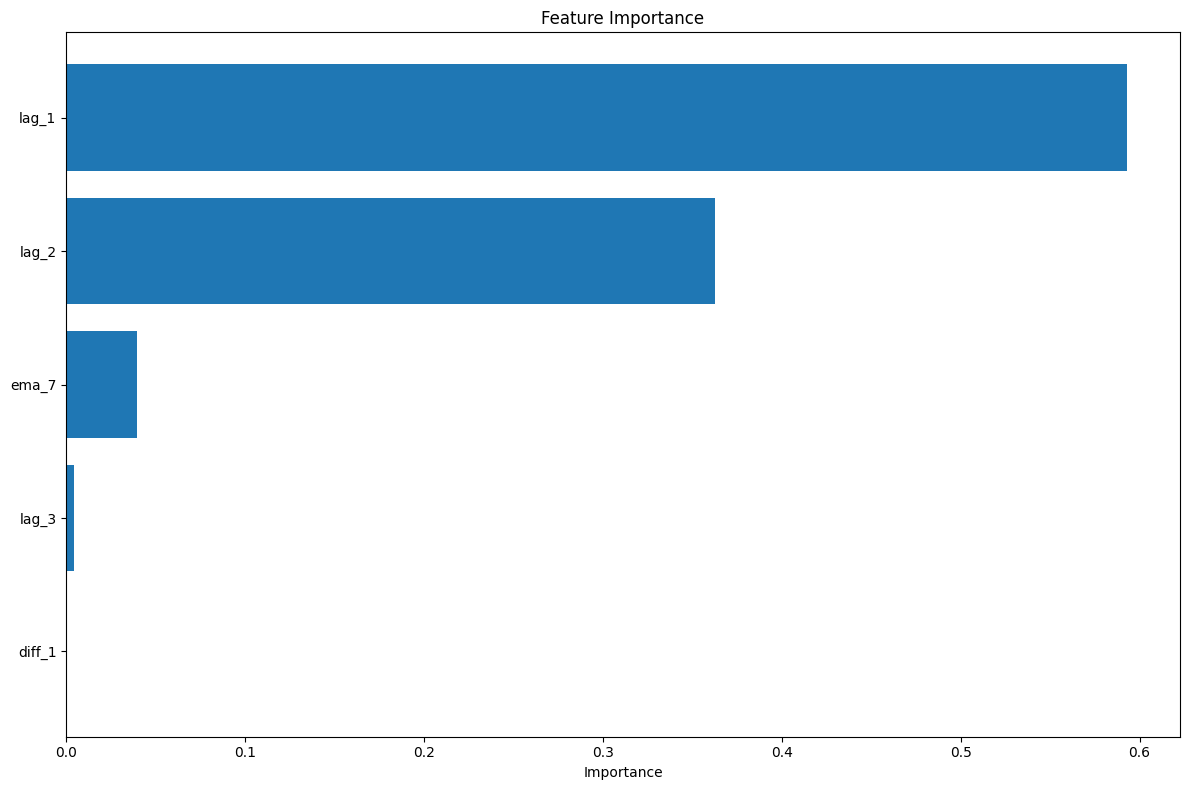

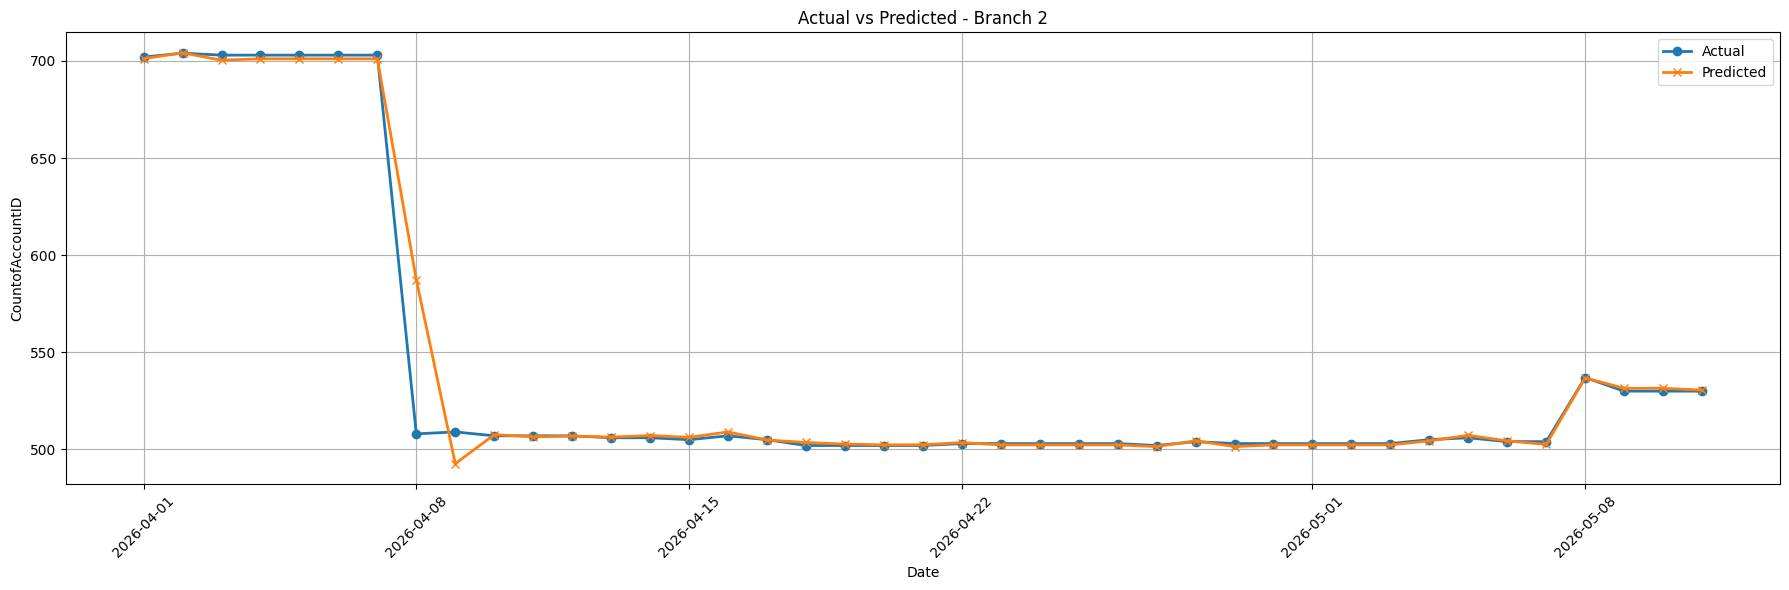

         Date  BranchID  Predicted_PAR
0  2026-05-12         2     530.464783
1  2026-05-13         2     530.531494
2  2026-05-14         2     530.531494
3  2026-05-15         2     530.664429
4  2026-05-16         2     530.664429
5  2026-05-17         2     530.664429
6  2026-05-18         2     530.664429
7  2026-05-19         2     530.664429
8  2026-05-20         2     530.664429
9  2026-05-21         2     530.664429
10 2026-05-22         2     530.664429
11 2026-05-23         2     530.664429
12 2026-05-24         2     530.664429


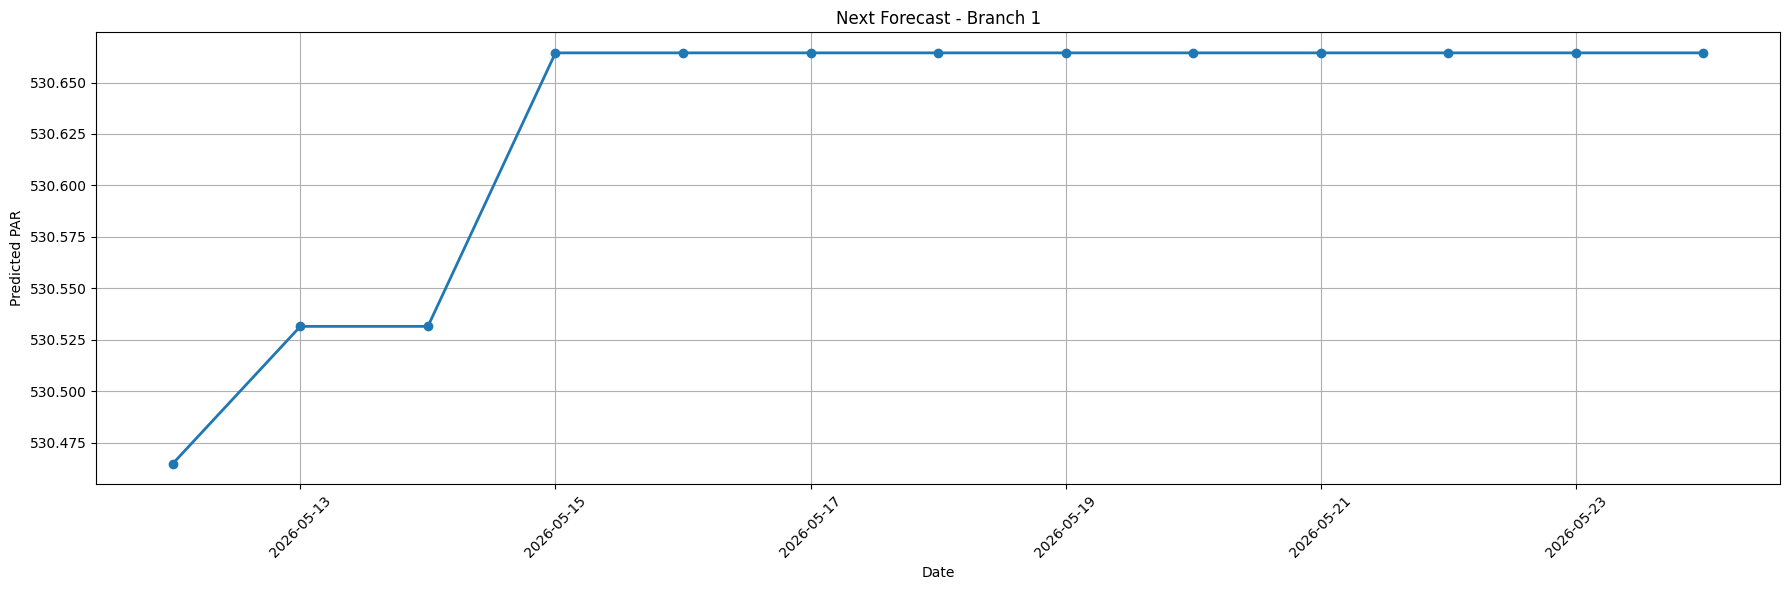

In [41]:
if __name__ == "__main__":
    main()